<a href="https://colab.research.google.com/github/tnc-br/ddf-isoscapes/blob/npr-working/brazil_cv_evals_for_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Isoscape Evals

Notebook Purpose: Eval isoscape generation methods for our paper

Isoscape Task: Find the mean/variance of O18 ratios (as well as N15 and C13 in the future) at a particular lat/lon across Brazil.

# Setup

## Fetch Dependencies

In [1]:
!pip install rasterio fiona pykrige

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 136.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.6/979.6 kB 13.3 MB/s eta 0:00:00


### If Doing Monte-Carlo: PyMC3 is not packaged properly. Install that.

In [ ]:
!pip install mkl-service versioneer

In [ ]:
!git clone https://github.com/pymc-devs/pymc3
!cd pymc3 && pip install -r requirements.txt

In [ ]:
!cd pymc3 && python setup.py install

In [ ]:
!rm -rf pymc3

## Import libraries required

In [1]:
import importlib
from datetime import datetime
import sys
import os

In [2]:
!if [ ! -d "/content/ddf_common_stub" ] ; then git clone -b test https://github.com/tnc-br/ddf_common_stub.git; fi
sys.path.append("/content/ddf_common_stub/")
import ddfimport
#ddfimport.ddf_import_common()
ddfimport.ddf_import_common("nicholas@rothemail.net", branch_name="cv-fixes")

executing checkout_branch cv-fixes...
b"fatal: destination path 'ddf_common' already exists and is not an empty directory.\nRepository already exists.\n"
b'Already up to date.\n'
b''
cv-fixes branch checked out at "/content/gdrive/MyDrive/cv-fixes/ddf_common". You may now use ddf_common imports and change common files.


interactive(children=(Text(value='required', description='Commit Msg', placeholder='Enter commit message'), Bu…

In [3]:
import train_variational_inference_model as tvim
import raster
import eeddf
import dataset
import model
import fiona
import rasterio.mask
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount(raster.GDRIVE_BASE)

# Leave test_environment=True. Experiments must be done in test.
eeddf.initialize_ddf(test_environment=True)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
# Patch https://github.com/tnc-br/ddf_common/issues/72 here
import evaluation
importlib.reload(evaluation)
importlib.reload(tvim)

<module 'train_variational_inference_model' from '/content/gdrive/MyDrive/cv-fixes/ddf_common/train_variational_inference_model.py'>

# Data configuration

In [ ]:
!cat {raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/uc_davis_train_fixed_grouped.csv'} <(tail -n+3 {raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/uc_davis_validation_fixed_grouped.csv'}) > /tmp/tmp.txt
!cat /tmp/tmp.txt <(tail -n+3 {raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/uc_davis_test_fixed_grouped.csv'}) > {raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/uc_davis_fixed_grouped_recombined.csv'}

In [5]:
# REQUIREMENTS:

# 1) Column names must match features_to_standardize, features_to_passthrough
# 2) Label columns in particular must match var_label and mean_label.
#
# If you used the data ingestion notebook (ingestion.ipynb) then this
# should be set up for you already.

# TRAINING FILE PARAMS
DATABASE_DIR = raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE
TRAINING_SET_FILE = 'canonical/uc_davis_fixed_grouped_recombined.csv' #@param
VALIDATION_SET_FILE = '' #@param
TEST_SET_FILE = '' #@param

# EVAL FILE PARAMS
EVAL_DATASET = '' #@param
#ORIGINAL_DATASET = 'canonical/2023_07_27_Results_google_utf8_latlonadded.csv' #@param
ORIGINAL_DATASET = 'canonical/2023_06_23_Results_Google.csv' #@param


fileset = {
    'TRAIN' : os.path.join(DATABASE_DIR, TRAINING_SET_FILE),
#    'TEST' : os.path.join(DATABASE_DIR, VALIDATION_SET_FILE),
#    'VALIDATION' : os.path.join(DATABASE_DIR, TEST_SET_FILE),
#    'EVAL' : os.path.join(DATABASE_DIR, EVAL_DATASET),
    'ORIGINAL' : os.path.join(DATABASE_DIR, ORIGINAL_DATASET)
}

def prepare_dataset(params: tvim.VIModelTrainingParams, files: dict) -> dataset.ScaledPartitions:
  # Prepared columns not in the original input-- these are engineered features
  # that we believe include strong signals, stored as geotiffs
  potentially_extra_columns = [
      "brisoscape_mean_ISORIX",
      "d13C_cel_mean",
      "d13C_cel_var",
      "ordinary_kriging_linear_d18O_predicted_mean",
      "ordinary_kriging_linear_d18O_predicted_variance",
  ]

  #Load the geotiff it the params request it.
  extra_columns_from_geotiffs = {}
  for feature in params.features_to_passthrough + params.features_to_standardize:
      if feature in potentially_extra_columns:
          extra_columns_from_geotiffs[feature] = raster.column_name_to_geotiff_fn[feature]()

  return dataset.load_and_scale(
      files,
      params.mean_label,
      params.var_label,
      params.features_to_passthrough,
      [],
      params.features_to_standardize,
      extra_columns_from_geotiffs)

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/bra_adm_ibge_2020_shp.zip') as shp:
  BRAZIL_SHP_MASK = [feature["geometry"] for feature in shp]

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/Amazon Biome.zip/data/commondata/data0') as shp:
  AMAZON_SHP_MASK = [feature["geometry"] for feature in shp]

# Load these lazily later from the first generated isoscapes

def display_brazil(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, BRAZIL_SHP_MASK, crop=False)
    out_meta = src.meta
    brazil_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, brazil_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

def display_amazon(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, AMAZON_SHP_MASK, crop=False)
    out_meta = src.meta
    amazon_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, amazon_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

# Non-VI Models

## Ordinary Kriging

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/00_ordinary.html

In [6]:
import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-okrige-2025-02-28-1", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "ordinary_kriging", "all_standardized", "gaussian_variogram", "cv", "rev1"], #@param
    n_cv_folds=5, #@param
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")


In [ ]:
data = prepare_dataset(params, fileset)

Driver: GTiff/GeoTIFF
Size is 541 x 467 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-73.922043, 5.233124)
Pixel Size = (0.08333, -0.08333)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0, 4.5)
Pixel Size = (0.16666668085106384, -0.1666666513761468)
Driver: GTiff/GeoTIFF
Size is 235 x 218 x 1
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTH

In [7]:
import pandas as pd
import numpy as np
import raster
import generate_isoscape
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from ast import Pass
from sklearn import metrics

raw_train = pd.read_csv(fileset['TRAIN'])

In [ ]:
class OrdinaryKrigingModel:
  def __init__(self, data):
    self.ok = None
    self.min_long = min(data.train.X['long'])
    self.max_long = max(data.train.X['long'])
    self.min_lat = min(data.train.X['lat'])
    self.max_lat = max(data.train.X['lat'])

  def fit(self, X_train, Y_train, validation_data, **kwargs):
    self.ok = OrdinaryKriging(X_train['lat'], X_train['long'], Y_train['d18O_cel_mean'], **kwargs)

  def score(self, X, y):
    predicted = self.predict_on_batch(X)
    return metrics.root_mean_squared_error(y, predicted)

  def predict_on_batch(self, X):
    # A DataFrame [means, vars]
    x_coords = []
    y_coords = []
    for _, row in X.iterrows():
      x_coords.append(row['lat'],)
      y_coords.append(row['long'],)
    means, vars = self.ok.execute("points", x_coords, y_coords)
    return np.array([means, vars]).T

  def gen_isoscape(self, params):

    # Predict the isotope values on the range of lattitude and longitude values
    # within the bounds of our VPD geotiff (should be Brazil-shaped), then save
    # for qualitative eval / display
    isoscape_long_values = np.linspace(self.min_long, self.max_long, params.resolution_x)
    isoscape_lat_values = np.linspace(self.min_lat, self.max_lat, params.resolution_y)

    means, variances  = self.ok.execute("grid", isoscape_long_values,
                                    isoscape_lat_values)
    self.ok.print_statistics()

    arbitrary_geotiff = raster.vapor_pressure_deficit_geotiff()
    base_bounds = raster.get_extent(arbitrary_geotiff.gdal_dataset)
    final_bounds = raster.create_bounds_from_res(params.resolution_x, params.resolution_y, base_bounds)

    all_predictions = np.ma.masked_array([means, variances], mask=[np.isnan(means), np.isnan(variances)]) # raster, lat, lon
    all_predictions = np.transpose(all_predictions, axes=[1, 2, 0]) # lat, lon, raster

    generate_isoscape.save_numpy_to_geotiff(final_bounds, all_predictions, ISOSCAPE_SAVE_LOCATION)

cv_outs = model.cross_val_with_best_model(lambda: OrdinaryKrigingModel(data),
                                          lambda m, x, y: m.score(x, y),
                                          data,
                                          n_cv_folds=5,
                                          # Model KW Args
                                          variogram_model='gaussian')
training_artifacts, final_model, cv_artifacts = cv_outs

Training fold #0 ||| (train_index_start: [ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24])
Training fold #1 ||| (train_index_start: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [25 26 27 28 

In [ ]:
cv_artifacts

{'loss_per_fold': {0: 1.0589812612149445,
  1: 0.9880587630839244,
  2: 1.6818164531018258,
  3: 5.773930304641812,
  4: 1.685528681442679},
 'mean_rmse': 1.4420932544580451,
 'var_rmse': 4.655029731518009}

In [ ]:
final_model.gen_isoscape(params)

Q1 = None
Q2 = None
cR = None
Driver: GTiff/GeoTIFF
Size is 941 x 937 x 12
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.04166666666665718, -0.04166666666667143)


In [ ]:
display_brazil(0) # Means

In [ ]:
display_amazon(0) # Means

In [ ]:
# Broken for cross-validation
#EVAL_ONLY = True
#res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

In [ ]:
params.tags

['author:npr',
 'ordinary_kriging',
 'all_standardized',
 'gaussian_variogram',
 'rev5']

## Universal Kriging

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/01_universal.html

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-ukrige-2025-02-28-1", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "universal_kriging", "all_standardized", "linear_variogram", "rev3"], #@param
    n_cv_folds=5,
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")


In [ ]:
data = prepare_dataset(params, fileset)

In [ ]:
import pandas as pd
import numpy as np
import raster
import pykrige.kriging_tools as kt
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error
raw_train = pd.read_csv(fileset['TRAIN'])

In [ ]:
class UniversalKrigingModel:
  def __init__(self, data):
    self.ok = None
    self.min_long = min(data.train.X['long'])
    self.max_long = max(data.train.X['long'])
    self.min_lat = min(data.train.X['lat'])
    self.max_lat = max(data.train.X['lat'])

  def fit(self, X_train, Y_train, validation_data, **kwargs):
    self.uk = UniversalKriging(X_train['lat'], X_train['long'], Y_train['d18O_cel_mean'], **kwargs)

  def score(self, X, y):
    predicted = self.predict_on_batch(X)
    return metrics.root_mean_squared_error(y, predicted)

  def predict_on_batch(self, X):
    # A DataFrame [means, vars]
    x_coords = []
    y_coords = []
    for _, row in X.iterrows():
      x_coords.append(row['lat'],)
      y_coords.append(row['long'],)
    means, vars = self.uk.execute("points", x_coords, y_coords)
    return np.array([means, vars]).T

  def gen_isoscape(self, params):

    # Predict the isotope values on the range of lattitude and longitude values
    # within the bounds of our VPD geotiff (should be Brazil-shaped), then save
    # for qualitative eval / display
    isoscape_long_values = np.linspace(self.min_long, self.max_long, params.resolution_x)
    isoscape_lat_values = np.linspace(self.min_lat, self.max_lat, params.resolution_y)

    means, variances  = self.uk.execute("grid", isoscape_long_values,
                                    isoscape_lat_values)
    self.uk.print_statistics()

    arbitrary_geotiff = raster.vapor_pressure_deficit_geotiff()
    base_bounds = raster.get_extent(arbitrary_geotiff.gdal_dataset)
    final_bounds = raster.create_bounds_from_res(params.resolution_x, params.resolution_y, base_bounds)

    all_predictions = np.ma.masked_array([means, variances], mask=[np.isnan(means), np.isnan(variances)]) # raster, lat, lon
    all_predictions = np.transpose(all_predictions, axes=[1, 2, 0]) # lat, lon, raster

    generate_isoscape.save_numpy_to_geotiff(final_bounds, all_predictions, ISOSCAPE_SAVE_LOCATION)

cv_outs = model.cross_val_with_best_model(lambda: UniversalKrigingModel(data),
                                          lambda m, x, y: m.score(x, y),
                                          data,
                                          n_cv_folds=5,
                                          # Model KW Args
                                          variogram_model='linear',
                                          drift_terms=['regional_linear'])
training_artifacts, final_model, cv_artifacts = cv_outs

Training fold #0 ||| (train_index_start: [ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24])
Training fold #1 ||| (train_index_start: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [25 26 27 28 

In [ ]:
cv_artifacts

{'loss_per_fold': {0: 1.0433355144284933,
  1: 0.9885915334510417,
  2: 1.652942441795498,
  3: 5.817128846393949,
  4: 2.4906336905258715},
 'mean_rmse': 1.4970101789266392,
 'var_rmse': 4.800897901120419}

In [ ]:
final_model.gen_isoscape(params)

Q1 = 0.37786487700856203
Q2 = 1.1743225240290407
cR = 1.4680155463953137


In [ ]:
display_brazil(0)

In [ ]:
# Broken for cross-validation
#EVAL_ONLY = True
#res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


## Regression Kriging

Based on https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/examples/07_regression_kriging2d.html

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "test-rkrige-2025-02-28-1", #@param
    num_epochs = -1,
    num_layers = -1,
    num_nodes_per_layer = -1,
    training_batch_size = -1,
    learning_rate = -1,
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = -1,
    double_sided_kl = False,
    kl_num_samples_from_pred_dist = 1,
    dropout_rate = -1,
    activation_func = "",
    features_to_standardize = ['VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = ['lat', 'long'], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "regression_kriging", "all_standardized", "rev2", "krige_type:regression", "variogram:gaussian", "n_estimators:100", "max_depth:20", "regression_strategy:gradientboosting"], #@param
    n_cv_folds = 5
)
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)


MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE, params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")

In [ ]:
data = prepare_dataset(params, fileset)

In [ ]:
import pandas as pd
import numpy as np
import raster
from numpy.typing import NDArray
from typing import Tuple, List

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import generate_isoscape
import model

from pykrige.rk import RegressionKriging

class RegressionKrigingModel:
  def __init__(self, data):
    self.rk = None
    self.min_long = min(data.train.X['long'])
    self.max_long = max(data.train.X['long'])
    self.min_lat = min(data.train.X['lat'])
    self.max_lat = max(data.train.X['lat'])
    self.training_cols = None

  # #@override
  def fit(self, X_train, Y_train, validation_data, regression_model, regression_kwargs, krige_kwargs):

    train_features = params.features_to_standardize + params.features_to_passthrough
    train_features_nolatlon = list(train_features)
    train_features_nolatlon.remove('lat')
    train_features_nolatlon.remove('long')

    p_train = X_train[train_features_nolatlon]
    self.training_cols = train_features_nolatlon
    x_train = np.array(tuple(zip(X_train['lat'], X_train['long'])))


    self.rk = RegressionKriging(regression_model=regression_model(**regression_kwargs), **krige_kwargs)
    # Why do I call .to_numpy() here?
    # to_numpy() removes feature names, which ColumnTransformer.transform() strips
    # in predict_on_batch(). If trained with feature names but inference is run
    # without, a long list of warnings will be printed and isoscape generation will
    # be slower.
    self.rk.fit(p_train.to_numpy(), x_train, Y_train[params.mean_label])

  # #@override
  def score(self, X, y):
    predicted = self.predict_on_batch(X)
    return metrics.root_mean_squared_error(y, predicted)

  # #@override
  def predict_on_batch(self, X: pd.DataFrame) -> NDArray[np.float32]:
    #TODO(ruru): Maybe our isoscape generator should standardize the features in features_to_standardize here as well
    #TODO: The scaling step appears to add some time. This might be a good target for future performance efforts.
    XT = data.feature_scaler.transform(X)
    latindex = X.columns.get_loc('lat')
    longindex = X.columns.get_loc('long')
    x = X[['lat', 'long']].to_numpy()
    p = np.delete(XT, [latindex, longindex],axis=1)
    means = self.rk.predict(p, x)
    return np.array([means, np.zeros(means.shape)]).T

  # #@override
  def training_column_names(self) -> List[str]:
    return ['lat', 'long'] + self.training_cols

  def gen_isoscape(self, params):
    generate_isoscape.generate_isoscapes_from_variational_model(self, 100, 100, ISOSCAPE_SAVE_LOCATION)


cv_outs = model.cross_val_with_best_model(lambda: RegressionKrigingModel(data),
                                          lambda m, x, y: m.score(x, y),
                                          data,
                                          n_cv_folds=5,
                                          # Model KW Args
                                          regression_model=GradientBoostingRegressor,
                                          regression_kwargs={'n_estimators':100, 'max_depth':20},
                                          krige_kwargs={'method': 'universal', 'variogram_model':'linear', 'drift_terms':['regional_linear']})
training_artifacts, final_model, cv_artifacts = cv_outs

Training fold #0 ||| (train_index_start: [ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24])
Finished learning regression model
Finished kriging residuals
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
Training fold #1 ||| (train_index_start: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87 

In [ ]:
cv_artifacts

{'loss_per_fold': {0: 0.8586627688022377,
  1: 1.0506110350049438,
  2: 1.2566311690998289,
  3: 5.8765545864362005,
  4: 1.6377076468646599},
 'mean_rmse': 1.568751267142775,
 'var_rmse': 4.461583596899634}

In [ ]:
final_model.gen_isoscape(params)

  4%|▍         | 4/100 [00:00<00:02, 33.20it/s]

n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


  8%|▊         | 8/100 [00:00<00:05, 16.57it/s]

n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


 11%|█         | 11/100 [00:00<00:05, 16.26it/s]

...

 95%|█████████▌| 95/100 [00:10<00:00,  9.82it/s]

n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


 99%|█████████▉| 99/100 [00:10<00:00, 11.80it/s]

n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


100%|██████████| 100/100 [00:10<00:00,  9.29it/s]


In [ ]:
display_brazil(0)

In [ ]:
display_amazon(0)

In [ ]:
# Broken for cross-validation
#EVAL_ONLY = True
#res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

# Variational Inference + DNN

In [ ]:
# Convenience links:
# Paper: https://braintex.goog/project/6509cbf324c22900a893d018
# Experiment list: https://docs.google.com/spreadsheets/d/1QUGvdUkkYCnflTytaYelMsbzGjhvR0U_HBkRdDUdeGM/edit?gid=1787854098#gid=1787854098
#

In [7]:
import tensorflow as tf

In [8]:
tf.keras.utils.set_random_seed(18731)


In [9]:
params = tvim.VIModelTrainingParams(
    training_id = "2025-02-28-vinn-1", #@param
    num_epochs = 5000, #@param
    num_layers = 2, #@param
    num_nodes_per_layer = 20, #@param
    training_batch_size = 5, #@param
    learning_rate = 0.00001, #@param
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = 100, #@param
    double_sided_kl = False, #@param
    kl_num_samples_from_pred_dist = 15, #@param
    dropout_rate = 0, #@param
    activation_func = "relu", #@param
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    tags = ["author:npr", "ViNN", "rev2"], #@param
    foo = "bar",
    n_cv_folds=5
)

eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)

MODEL_SAVE_LOCATION = os.path.join(raster.GDRIVE_BASE, raster.MODEL_BASE.lstrip('/'), params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")

# Train the model

2025-02-28-vinn-1
Training fold #0 ||| (train_index_start: [ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121], val_index_start: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 16)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 20)             │            340 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 20)             │            420 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ var_output (Dense)        │ (None, 1)              │             21 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mean_output (Dense)       │ (None, 1)              │             21 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 1)              │              0 │ var_output[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 1)              │              0 │ mean_output[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 1)              │              0 │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 1)              │              0 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast (Cast)               │ (None, 1)              │              0 │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_1 (Cast)             │ (None, 1)              │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ softplus_layer            │ (None, 1)              │              0 │ cast[0][0]             │
│ (SoftplusLayer)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 2)              │              0 │ cast_1[0][0],          │
│                           │                        │                │ softplus_layer[0][0]   │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 802 (3.13 KB)

 Trainable params: 802 (3.13 KB)

...

 Trainable params: 802 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 3.2915 - val_loss: 3.0249
Epoch 2/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.5970 - val_loss: 2.8271
Epoch 3/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2865 - val_loss: 2.3457
Epoch 4/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3636 - val_loss: 2.2955
Epoch 5/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2066 - val_loss: 2.4360
Epoch 6/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1076 - val_loss: 2.5153
Epoch 7/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.2497 - val_loss: 2.2303
Epoch 8/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3766 - val_loss: 2.0356
Epoch 9/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9691 - val_loss: 1.9209
Epoch 10/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1741 - val_loss: 2.0643
Epoch 11/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0219 - val_loss: 2.3099
Epoch 12/5000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s

/content/gdrive/MyDrive/cv-fixes/ddf_common/model.py:352: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0, 10))


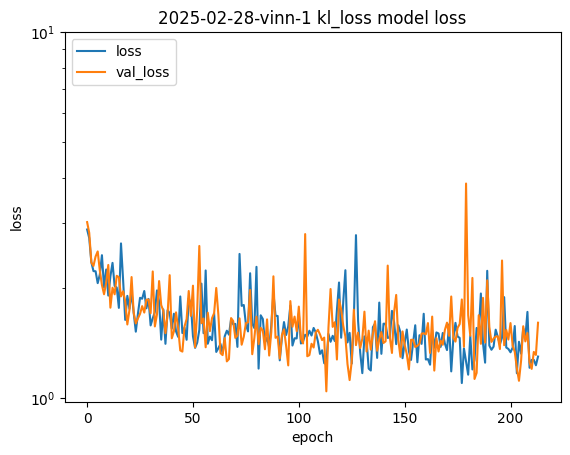

Val loss: 1.042719841003418
Train loss: 1.2391741275787354


100%|██████████| 1024/1024 [01:37<00:00, 10.52it/s]


Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)
Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


KeyError: 'EVAL'

In [ ]:
EVAL_ONLY = False #@param{type:'boolean'}
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY)

# Optional Rendering

In [ ]:
from matplotlib import rc
rc('animation', html='jshtml')

means_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=0)
raster.animate(means_isoscape,  1, 1)

Driver: GTiff/GeoTIFF
Size is 1024 x 1024 x 2
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.03828938802082461, -0.03812662760417103)


In [ ]:
vars_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=1)
raster.animate(vars_isoscape,  1, 1)